
GREY WOLF OPTIMIZATION

Number of Wolves : 30
Iterations       : 50
Independent Runs : 30
Search Space     : [-5.0, 5.0]

[1/7] Creating manual calculation...
[OK] Manual calculation saved: GWO_results\Manual_Rosenbrock.md
[OK] Manual calculation saved: GWO_results\Manual_Rastrigin.md

[2/7] Running single GWO...

Rosenbrock Single Run
Best Position = [0.97579495 0.95286129]
Best Fitness  = 0.0006328754669718117

Rastrigin Single Run
Best Position = [ 2.65439588e-09 -9.67887588e-10]
Best Fitness  = 0.0

[3/7] Creating movement graphs...
[OK] Rosenbrock: 51 frames created.
[OK] Rastrigin: 51 frames created.

[4/7] Creating GIF animations...
[OK] GIF created: GWO_results\Rosenbrock_GWO.gif
[OK] GIF created: GWO_results\Rastrigin_GWO.gif

[5/7] Creating distance graphs...


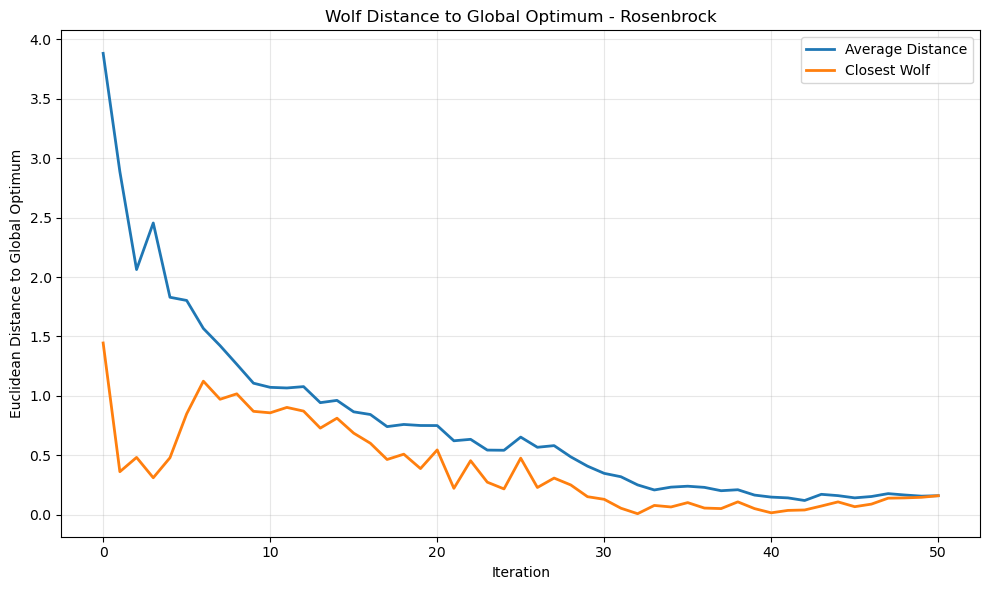

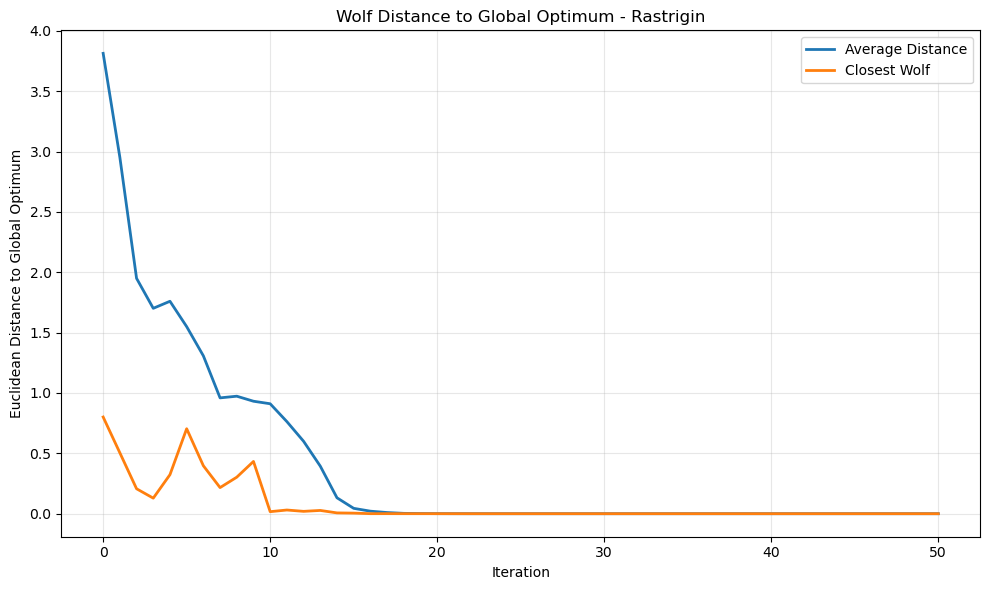


[6/7] Running 30 independent runs...

ROSENBROCK
Best Fitness   : 0.0000088987
Mean Fitness   : 0.0113161825
Worst Fitness  : 0.0545998849
Std Deviation  : 0.0145523500
Avg Runtime    : 0.070868 sec

RASTRIGIN
Best Fitness   : 0.0000000000
Mean Fitness   : 0.1907454719
Worst Fitness  : 1.4650281699
Std Deviation  : 0.4122929170
Avg Runtime    : 0.071829 sec

[7/7] Creating convergence graph...


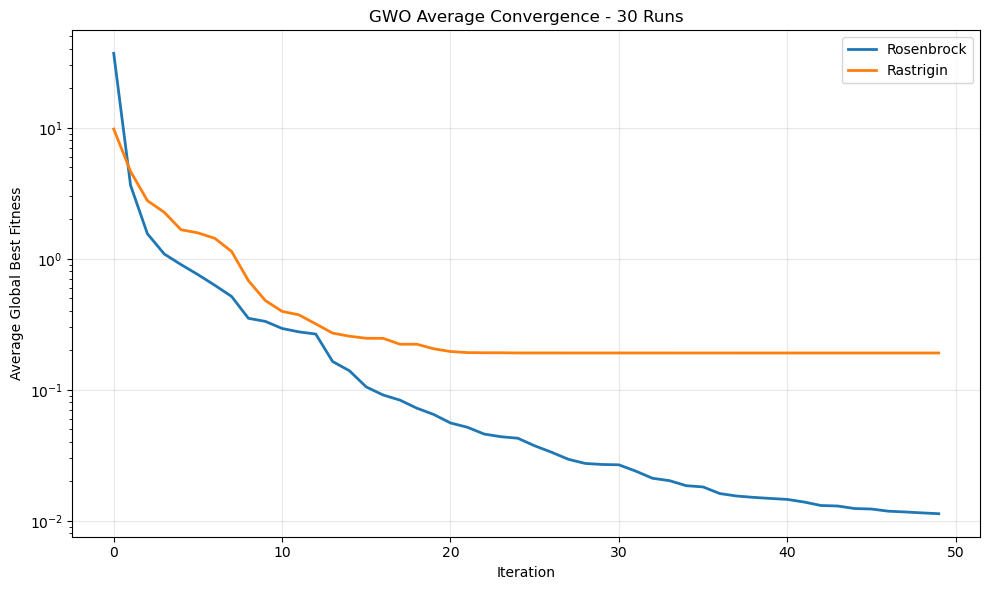

[OK] Distance data saved: GWO_results\Rosenbrock_Distance_Data.txt
[OK] Distance data saved: GWO_results\Rastrigin_Distance_Data.txt

ALL OUTPUTS CREATED

GWO_results/
│
├── Manual_Rosenbrock.md
├── Manual_Rastrigin.md
│
├── Rosenbrock_Every_Iteration/
│   ├── frame_00.png
│   ├── frame_01.png
│   ├── frame_02.png
│   ├── ...
│   └── frame_50.png
│
├── Rastrigin_Every_Iteration/
│   ├── frame_00.png
│   ├── frame_01.png
│   ├── frame_02.png
│   ├── ...
│   └── frame_50.png
│
├── Rosenbrock_GWO.gif
├── Rastrigin_GWO.gif
│
├── Rosenbrock_Distance.png
├── Rastrigin_Distance.png
│
├── Rosenbrock_Distance_Data.txt
├── Rastrigin_Distance_Data.txt
│
└── Average_Convergence_30_Runs.png


Finished.


In [5]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# GREY WOLF OPTIMIZATION (GWO)
# ============================================================
#
# Objective Functions:
#   1. Rosenbrock
#   2. Rastrigin
#
# GWO Parameters:
#   Number of Wolves = 30
#   Maximum Iterations = 50
#   Number of Runs = 30
#   Dimension = 2
#
# Output:
#   - Manual calculation
#   - Best / Mean / Worst / Std
#   - Average Runtime
#   - Convergence Curve
#   - Wolf movement every iteration
#   - Wolf trajectory
#   - Distance from global optimum
#   - GIF animation
#
# ============================================================


# ============================================================
# 1. OBJECTIVE FUNCTIONS
# ============================================================

def rosenbrock(position):
    """
    Rosenbrock Function

    Equation:

        f(x,y)
        = (1 - x)^2
        + 100(y - x^2)^2

    Global optimum:

        (x, y) = (1, 1)

    Minimum fitness:

        f(1,1) = 0
    """

    x, y = position

    return (
        (1 - x) ** 2
        + 100 * (y - x ** 2) ** 2
    )


def rastrigin(position):
    """
    Rastrigin Function

    Equation:

        f(x,y)
        = 20 + x^2 + y^2
        - 10[cos(2*pi*x) + cos(2*pi*y)]

    Global optimum:

        (x, y) = (0, 0)

    Minimum fitness:

        f(0,0) = 0
    """

    x, y = position

    return (
        20
        + x ** 2
        + y ** 2
        - 10 * (
            np.cos(2 * np.pi * x)
            + np.cos(2 * np.pi * y)
        )
    )


# ============================================================
# 2. GLOBAL OPTIMUM
# ============================================================

def get_global_optimum(function_name):

    if function_name == "Rosenbrock":

        return np.array([1.0, 1.0])

    elif function_name == "Rastrigin":

        return np.array([0.0, 0.0])

    else:

        raise ValueError(
            "Unknown function name"
        )


# ============================================================
# 3. GREY WOLF OPTIMIZATION
# ============================================================

def gwo(
    objective_function,
    lower_bound=-5.0,
    upper_bound=5.0,
    dimension=2,
    num_wolves=30,
    max_iterations=50,
    seed=42
):

    """
    Grey Wolf Optimization

    --------------------------------------------------------
    GWO algorithm
    --------------------------------------------------------

    1. Initialize wolf population

    2. Evaluate fitness

    3. Select:

       Alpha
       Beta
       Delta

    4. Calculate parameter a

    5. Calculate A and C

    6. Calculate D_alpha, D_beta, D_delta

    7. Calculate X1, X2, X3

    8. Update wolf position

    --------------------------------------------------------
    """

    # --------------------------------------------------------
    # Random number generator
    # --------------------------------------------------------

    rng = np.random.default_rng(seed)


    # ========================================================
    # INITIAL POPULATION
    # ========================================================
    #
    # Each wolf starts from a different random position.
    #
    # Search space:
    #
    #     -5 <= x <= 5
    #     -5 <= y <= 5
    #
    # This is better than putting every wolf at exactly
    # the same position because GWO should explore the
    # search space.
    # ========================================================

    positions = rng.uniform(
        lower_bound,
        upper_bound,
        size=(num_wolves, dimension)
    )


    # ========================================================
    # STORAGE
    # ========================================================

    # Store all wolf positions.
    #
    # positions_history[0]
    # = initial population
    #
    # positions_history[1]
    # = population after iteration 1
    #
    # ...
    #
    # positions_history[50]
    # = population after iteration 50

    positions_history = [
        positions.copy()
    ]


    # Store Alpha / Beta / Delta

    alpha_history = []
    beta_history = []
    delta_history = []


    # Store Alpha fitness

    alpha_fitness_history = []


    # Store global best

    global_best_score = np.inf

    global_best_position = np.zeros(
        dimension
    )


    # Store global best every iteration

    global_best_history = []


    # Distance from known optimum

    average_distance_history = []

    closest_distance_history = []


    # ========================================================
    # KNOWN GLOBAL OPTIMUM
    # ========================================================

    if objective_function == rosenbrock:

        known_optimum = np.array(
            [1.0, 1.0]
        )

    elif objective_function == rastrigin:

        known_optimum = np.array(
            [0.0, 0.0]
        )

    else:

        known_optimum = None


    # ========================================================
    # START TIMER
    # ========================================================

    start_time = time.perf_counter()


    # ========================================================
    # MAIN GWO LOOP
    # ========================================================

    for iteration in range(
        max_iterations
    ):

        # ====================================================
        # STEP 1
        # Calculate fitness
        # ====================================================

        fitness = np.array([
            objective_function(wolf)
            for wolf in positions
        ])


        # ====================================================
        # STEP 2
        # Select Alpha, Beta, Delta
        # ====================================================
        #
        # Since this is a minimization problem:
        #
        # Smaller fitness = better wolf
        #
        # ====================================================

        sorted_indices = np.argsort(
            fitness
        )


        alpha_index = sorted_indices[0]

        beta_index = sorted_indices[1]

        delta_index = sorted_indices[2]


        alpha_pos = positions[
            alpha_index
        ].copy()


        beta_pos = positions[
            beta_index
        ].copy()


        delta_pos = positions[
            delta_index
        ].copy()


        alpha_score = fitness[
            alpha_index
        ]


        # ====================================================
        # GLOBAL BEST
        # ====================================================

        if alpha_score < global_best_score:

            global_best_score = float(
                alpha_score
            )

            global_best_position = (
                alpha_pos.copy()
            )


        # ====================================================
        # SAVE LEADER INFORMATION
        # ====================================================

        alpha_history.append(
            alpha_pos.copy()
        )

        beta_history.append(
            beta_pos.copy()
        )

        delta_history.append(
            delta_pos.copy()
        )

        alpha_fitness_history.append(
            float(alpha_score)
        )


        global_best_history.append(
            float(global_best_score)
        )


        # ====================================================
        # DISTANCE FROM GLOBAL OPTIMUM
        # ====================================================
        #
        # Euclidean distance:
        #
        # d = sqrt(
        #       (x - x*)^2
        #       +
        #       (y - y*)^2
        #     )
        #
        # IMPORTANT:
        # This distance is ONLY used for visualization.
        # It is NOT part of GWO.
        # ====================================================

        if known_optimum is not None:

            distances = np.linalg.norm(
                positions - known_optimum,
                axis=1
            )

            average_distance_history.append(
                float(
                    np.mean(distances)
                )
            )

            closest_distance_history.append(
                float(
                    np.min(distances)
                )
            )


        # ====================================================
        # STEP 3
        # Calculate parameter a
        # ====================================================
        #
        # Standard linear decreasing equation:
        #
        #     a = 2 - 2*t/(T-1)
        #
        # where:
        #
        #     t = current iteration
        #     T = total iterations
        #
        # At first iteration:
        #
        #     a = 2
        #
        # At final iteration:
        #
        #     a = 0
        #
        # ====================================================

        if max_iterations > 1:

            a = (
                2
                - (
                    2 * iteration
                    / (max_iterations - 1)
                )
            )

        else:

            a = 0


        # ====================================================
        # STEP 4
        # UPDATE EVERY WOLF
        # ====================================================

        new_positions = np.zeros_like(
            positions
        )


        for wolf in range(
            num_wolves
        ):

            # =================================================
            # ALPHA
            # =================================================
            #
            # Equation:
            #
            #     A = 2*a*r1 - a
            #
            #     C = 2*r2
            #
            #     D_alpha
            #     = |C*X_alpha - X|
            #
            #     X1
            #     = X_alpha - A*D_alpha
            #
            # =================================================

            r1_alpha = rng.random(
                dimension
            )

            r2_alpha = rng.random(
                dimension
            )


            # Equation:
            # A1 = 2*a*r1 - a

            A1 = (
                2 * a * r1_alpha
                - a
            )


            # Equation:
            # C1 = 2*r2

            C1 = (
                2 * r2_alpha
            )


            # Equation:
            #
            # D_alpha
            # = |C1*X_alpha - X|

            D_alpha = np.abs(
                C1 * alpha_pos
                - positions[wolf]
            )


            # Equation:
            #
            # X1
            # = X_alpha - A1*D_alpha

            X1 = (
                alpha_pos
                - A1 * D_alpha
            )


            # =================================================
            # BETA
            # =================================================
            #
            # Equation:
            #
            # A2 = 2*a*r1 - a
            #
            # C2 = 2*r2
            #
            # D_beta
            # = |C2*X_beta - X|
            #
            # X2
            # = X_beta - A2*D_beta
            #
            # =================================================

            r1_beta = rng.random(
                dimension
            )

            r2_beta = rng.random(
                dimension
            )


            A2 = (
                2 * a * r1_beta
                - a
            )


            C2 = (
                2 * r2_beta
            )


            D_beta = np.abs(
                C2 * beta_pos
                - positions[wolf]
            )


            X2 = (
                beta_pos
                - A2 * D_beta
            )


            # =================================================
            # DELTA
            # =================================================
            #
            # Equation:
            #
            # A3 = 2*a*r1 - a
            #
            # C3 = 2*r2
            #
            # D_delta
            # = |C3*X_delta - X|
            #
            # X3
            # = X_delta - A3*D_delta
            #
            # =================================================

            r1_delta = rng.random(
                dimension
            )

            r2_delta = rng.random(
                dimension
            )


            A3 = (
                2 * a * r1_delta
                - a
            )


            C3 = (
                2 * r2_delta
            )


            D_delta = np.abs(
                C3 * delta_pos
                - positions[wolf]
            )


            X3 = (
                delta_pos
                - A3 * D_delta
            )


            # =================================================
            # UPDATE POSITION
            # =================================================
            #
            # Main GWO equation:
            #
            # X(t+1)
            # = (X1 + X2 + X3) / 3
            #
            # =================================================

            new_positions[wolf] = (
                X1
                + X2
                + X3
            ) / 3


        # ====================================================
        # BOUNDARY HANDLING
        # ====================================================
        #
        # Keep wolves inside search space.
        # ====================================================

        positions = np.clip(
            new_positions,
            lower_bound,
            upper_bound
        )


        # ====================================================
        # SAVE NEW POPULATION
        # ====================================================

        positions_history.append(
            positions.copy()
        )


    # ========================================================
    # END TIMER
    # ========================================================

    runtime = (
        time.perf_counter()
        - start_time
    )


    # ========================================================
    # RETURN EVERYTHING
    # ========================================================

    return {

        "best_score":
            float(global_best_score),

        "best_position":
            global_best_position.copy(),

        "runtime":
            runtime,

        "positions_history":
            positions_history,

        "alpha_history":
            alpha_history,

        "beta_history":
            beta_history,

        "delta_history":
            delta_history,

        "alpha_fitness_history":
            np.array(
                alpha_fitness_history
            ),

        "global_best_history":
            np.array(
                global_best_history
            ),

        "average_distance_history":
            np.array(
                average_distance_history
            ),

        "closest_distance_history":
            np.array(
                closest_distance_history
            )
    }


# ============================================================
# 4. CREATE FUNCTION CONTOUR
# ============================================================

def create_function_grid(
    objective_function,
    lower_bound=-5,
    upper_bound=5,
    resolution=200
):

    x = np.linspace(
        lower_bound,
        upper_bound,
        resolution
    )

    y = np.linspace(
        lower_bound,
        upper_bound,
        resolution
    )


    X, Y = np.meshgrid(
        x,
        y
    )


    Z = np.zeros_like(
        X
    )


    for i in range(
        resolution
    ):

        for j in range(
            resolution
        ):

            Z[i, j] = (
                objective_function(
                    [
                        X[i, j],
                        Y[i, j]
                    ]
                )
            )


    return X, Y, Z


# ============================================================
# 5. PLOT EVERY ITERATION
# ============================================================

def plot_every_iteration(
    result,
    objective_function,
    function_name,
    output_folder,
    lower_bound=-5,
    upper_bound=5
):

    """
    Create one graph for EVERY iteration.

    Output:

        frame_00.png
        frame_01.png
        frame_02.png
        ...
        frame_50.png

    frame_00 = initial population

    frame_01 = after iteration 1

    ...

    frame_50 = after iteration 50
    """

    os.makedirs(
        output_folder,
        exist_ok=True
    )


    positions_history = (
        result[
            "positions_history"
        ]
    )

    alpha_history = (
        result[
            "alpha_history"
        ]
    )

    beta_history = (
        result[
            "beta_history"
        ]
    )

    delta_history = (
        result[
            "delta_history"
        ]
    )

    global_best_history = (
        result[
            "global_best_history"
        ]
    )


    optimum = get_global_optimum(
        function_name
    )


    # ========================================================
    # Create contour
    # ========================================================

    X, Y, Z = create_function_grid(
        objective_function,
        lower_bound,
        upper_bound
    )


    # Log scale ONLY for visualization.
    #
    # The actual fitness is NOT changed.

    Z_visual = np.log1p(
        Z
    )


    total_frames = len(
        positions_history
    )


    # ========================================================
    # CREATE EACH FRAME
    # ========================================================

    for frame in range(
        total_frames
    ):

        fig, ax = plt.subplots(
            figsize=(9, 8)
        )


        # ====================================================
        # Background objective function
        # ====================================================

        contour = ax.contourf(
            X,
            Y,
            Z_visual,
            levels=40,
            cmap="viridis"
        )


        fig.colorbar(
            contour,
            ax=ax,
            label="log(1 + Fitness)"
        )


        # ====================================================
        # Current wolf positions
        # ====================================================

        current_positions = (
            positions_history[frame]
        )


        # ====================================================
        # Draw trajectory of every wolf
        # ====================================================

        for wolf_id in range(
            current_positions.shape[0]
        ):

            trajectory = np.array([
                positions_history[k][wolf_id]
                for k in range(
                    frame + 1
                )
            ])


            ax.plot(
                trajectory[:, 0],
                trajectory[:, 1],
                linewidth=0.8,
                alpha=0.30
            )


        # ====================================================
        # Draw wolves
        # ====================================================

        ax.scatter(
            current_positions[:, 0],
            current_positions[:, 1],
            s=45,
            label="Wolves",
            zorder=5
        )


        # ====================================================
        # Leader positions
        # ====================================================
        #
        # frame 0:
        # use leaders selected from initial population
        #
        # frame > 0:
        # use leader information of the corresponding
        # optimization iteration.
        # ====================================================

        leader_index = min(
            frame,
            len(alpha_history) - 1
        )


        alpha = (
            alpha_history[
                leader_index
            ]
        )

        beta = (
            beta_history[
                leader_index
            ]
        )

        delta = (
            delta_history[
                leader_index
            ]
        )


        # ====================================================
        # Alpha
        # ====================================================

        ax.scatter(
            alpha[0],
            alpha[1],
            marker="*",
            s=300,
            edgecolors="black",
            linewidths=1.5,
            label="Alpha",
            zorder=10
        )


        # ====================================================
        # Beta
        # ====================================================

        ax.scatter(
            beta[0],
            beta[1],
            marker="D",
            s=90,
            edgecolors="black",
            linewidths=1.2,
            label="Beta",
            zorder=10
        )


        # ====================================================
        # Delta
        # ====================================================

        ax.scatter(
            delta[0],
            delta[1],
            marker="s",
            s=90,
            edgecolors="black",
            linewidths=1.2,
            label="Delta",
            zorder=10
        )


        # ====================================================
        # Global optimum
        # ====================================================

        ax.scatter(
            optimum[0],
            optimum[1],
            marker="X",
            s=300,
            edgecolors="black",
            linewidths=1.5,
            label="Global Optimum",
            zorder=15
        )


        # ====================================================
        # Distance from optimum
        # ====================================================

        distances = np.linalg.norm(
            current_positions
            - optimum,
            axis=1
        )


        average_distance = (
            np.mean(distances)
        )


        closest_distance = (
            np.min(distances)
        )


        # ====================================================
        # Current best fitness
        # ====================================================

        current_fitness = np.array([
            objective_function(wolf)
            for wolf in current_positions
        ])


        current_best = np.min(
            current_fitness
        )


        if frame == 0:

            best_fitness = (
                current_best
            )

        else:

            best_fitness = (
                global_best_history[
                    frame - 1
                ]
            )


        # ====================================================
        # Title
        # ====================================================

        ax.set_title(
            f"GWO - {function_name}\n"
            f"Iteration {frame} / "
            f"{total_frames - 1}\n"
            f"Best Fitness = "
            f"{best_fitness:.8f}\n"
            f"Average Distance = "
            f"{average_distance:.4f}\n"
            f"Closest Wolf = "
            f"{closest_distance:.4f}"
        )


        ax.set_xlabel(
            "x"
        )

        ax.set_ylabel(
            "y"
        )


        ax.set_xlim(
            lower_bound,
            upper_bound
        )

        ax.set_ylim(
            lower_bound,
            upper_bound
        )


        ax.grid(
            alpha=0.20
        )


        ax.legend(
            loc="upper right"
        )


        plt.tight_layout()


        # ====================================================
        # Save frame
        # ====================================================

        filename = os.path.join(
            output_folder,
            f"frame_{frame:02d}.png"
        )


        plt.savefig(
            filename,
            dpi=140
        )


        plt.close(
            fig
        )


    print(
        f"[OK] {function_name}: "
        f"{total_frames} frames created."
    )


# ============================================================
# 6. CREATE GIF
# ============================================================

def create_gif(
    image_folder,
    output_file,
    fps=4
):

    """
    Create GIF from frame PNG files.
    """

    try:

        from PIL import Image

    except ImportError:

        print(
            "\n[WARNING]"
        )

        print(
            "Pillow is not installed."
        )

        print(
            "Install with:"
        )

        print(
            "pip install pillow"
        )

        return


    frame_files = sorted([
        os.path.join(
            image_folder,
            file
        )

        for file in os.listdir(
            image_folder
        )

        if file.endswith(
            ".png"
        )
    ])


    if len(frame_files) == 0:

        print(
            "No PNG frames found."
        )

        return


    images = [
        Image.open(
            file
        ).convert(
            "RGB"
        )

        for file in frame_files
    ]


    duration = int(
        1000 / fps
    )


    images[0].save(
        output_file,
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=0
    )


    for image in images:

        image.close()


    print(
        f"[OK] GIF created: "
        f"{output_file}"
    )


# ============================================================
# 7. PLOT CONVERGENCE CURVE
# ============================================================

def plot_convergence(
    metrics_rosenbrock,
    metrics_rastrigin,
    output_file
):

    """
    Average convergence curve from 30 independent runs.

    Lower fitness = better.
    """

    plt.figure(
        figsize=(10, 6)
    )


    epsilon = 1e-12


    plt.plot(
        np.maximum(
            metrics_rosenbrock[
                "Avg_Curve"
            ],
            epsilon
        ),
        linewidth=2,
        label="Rosenbrock"
    )


    plt.plot(
        np.maximum(
            metrics_rastrigin[
                "Avg_Curve"
            ],
            epsilon
        ),
        linewidth=2,
        label="Rastrigin"
    )


    plt.xlabel(
        "Iteration"
    )


    plt.ylabel(
        "Average Global Best Fitness"
    )


    plt.title(
        "GWO Average Convergence - 30 Runs"
    )


    # Log scale helps visualize small fitness values.

    plt.yscale(
        "log"
    )


    plt.grid(
        alpha=0.30
    )


    plt.legend()


    plt.tight_layout()


    plt.savefig(
        output_file,
        dpi=150
    )


    plt.show()


    plt.close()


# ============================================================
# 8. DISTANCE GRAPH
# ============================================================

def plot_distance_progress(
    result,
    function_name,
    output_file
):

    """
    Plot:

        Average Distance
        Closest Wolf Distance

    from known global optimum.
    """

    optimum = get_global_optimum(
        function_name
    )


    positions_history = (
        result[
            "positions_history"
        ]
    )


    average_distance = []

    closest_distance = []


    # ========================================================
    # Calculate distance for every frame
    # ========================================================

    for positions in (
        positions_history
    ):

        distances = np.linalg.norm(
            positions - optimum,
            axis=1
        )


        average_distance.append(
            np.mean(distances)
        )


        closest_distance.append(
            np.min(distances)
        )


    # ========================================================
    # Plot
    # ========================================================

    plt.figure(
        figsize=(10, 6)
    )


    plt.plot(
        average_distance,
        linewidth=2,
        label="Average Distance"
    )


    plt.plot(
        closest_distance,
        linewidth=2,
        label="Closest Wolf"
    )


    plt.xlabel(
        "Iteration"
    )


    plt.ylabel(
        "Euclidean Distance to Global Optimum"
    )


    plt.title(
        f"Wolf Distance to Global Optimum - "
        f"{function_name}"
    )


    plt.grid(
        alpha=0.30
    )


    plt.legend()


    plt.tight_layout()


    plt.savefig(
        output_file,
        dpi=150
    )


    plt.show()


    plt.close()


# ============================================================
# 9. 30-RUN EVALUATION
# ============================================================

def evaluate_30_runs(
    objective_function,
    num_runs=30,
    num_wolves=30,
    max_iterations=50
):

    """
    Run GWO 30 independent times.

    Metrics:

        Best
        Mean
        Worst
        Standard Deviation
        Average Runtime
        Average Convergence
    """

    best_scores = []

    runtimes = []

    convergence_curves = []


    for run in range(
        num_runs
    ):

        result = gwo(

            objective_function,

            lower_bound=-5,

            upper_bound=5,

            dimension=2,

            num_wolves=num_wolves,

            max_iterations=max_iterations,

            # Different seed for each run
            seed=1000 + run
        )


        best_scores.append(
            result[
                "best_score"
            ]
        )


        runtimes.append(
            result[
                "runtime"
            ]
        )


        convergence_curves.append(
            result[
                "global_best_history"
            ]
        )


    convergence_curves = np.array(
        convergence_curves
    )


    return {

        "Best":
            float(
                np.min(
                    best_scores
                )
            ),

        "Mean":
            float(
                np.mean(
                    best_scores
                )
            ),

        "Worst":
            float(
                np.max(
                    best_scores
                )
            ),

        "Std":
            float(
                np.std(
                    best_scores
                )
            ),

        "Avg_Runtime":
            float(
                np.mean(
                    runtimes
                )
            ),

        "Avg_Curve":
            np.mean(
                convergence_curves,
                axis=0
            )
    }


# ============================================================
# 10. PRINT METRICS
# ============================================================

def print_metrics(
    function_name,
    metrics
):

    print()
    print("=" * 65)

    print(
        f"{function_name}"
    )

    print("=" * 65)

    print(
        f"Best Fitness   : "
        f"{metrics['Best']:.10f}"
    )

    print(
        f"Mean Fitness   : "
        f"{metrics['Mean']:.10f}"
    )

    print(
        f"Worst Fitness  : "
        f"{metrics['Worst']:.10f}"
    )

    print(
        f"Std Deviation  : "
        f"{metrics['Std']:.10f}"
    )

    print(
        f"Avg Runtime    : "
        f"{metrics['Avg_Runtime']:.6f} sec"
    )


# ============================================================
# 11. MANUAL CALCULATION
# ============================================================

def generate_manual_calculation(
    objective_function,
    function_name,
    output_file
):

    """
    Generate a Markdown file demonstrating
    2 iterations of GWO.

    Initial positions are fixed so the values can
    be reproduced.
    """

    # ========================================================
    # Initial positions
    # ========================================================
    #
    # Five wolves are used so the calculation is still
    # readable in a presentation.
    #
    # They are intentionally spread around the search space.
    # ========================================================

    positions = np.array([

        [-4.0, 4.0],

        [-2.0, 3.0],

        [0.0, 2.0],

        [2.0, -1.0],

        [4.0, 3.0]

    ])


    rng = np.random.default_rng(
        42
    )


    with open(
        output_file,
        "w",
        encoding="utf-8"
    ) as file:

        file.write(
            "# GWO Manual Calculation\n\n"
        )


        file.write(
            f"## Function: "
            f"{function_name}\n\n"
        )


        file.write(
            "## Initial Positions\n\n"
        )


        for i, position in enumerate(
            positions,
            start=1
        ):

            file.write(
                f"- Wolf {i}: "
                f"[{position[0]:.4f}, "
                f"{position[1]:.4f}]\n"
            )


        file.write(
            "\n---\n\n"
        )


        # ====================================================
        # 2 manual iterations
        # ====================================================

        T = 2


        for t in range(
            T
        ):

            file.write(
                f"# Iteration {t + 1}\n\n"
            )


            # =================================================
            # FITNESS
            # =================================================

            fitness = np.array([

                objective_function(
                    wolf
                )

                for wolf in positions

            ])


            order = np.argsort(
                fitness
            )


            alpha = positions[
                order[0]
            ].copy()


            beta = positions[
                order[1]
            ].copy()


            delta = positions[
                order[2]
            ].copy()


            file.write(
                "## 1. Fitness\n\n"
            )


            for i in range(
                len(positions)
            ):

                file.write(
                    f"- Wolf {i + 1}: "
                    f"Position = "
                    f"[{positions[i,0]:.4f}, "
                    f"{positions[i,1]:.4f}] "
                    f"-> Fitness = "
                    f"{fitness[i]:.8f}\n"
                )


            file.write(
                "\n## Leaders\n\n"
            )


            file.write(
                f"- Alpha = "
                f"[{alpha[0]:.4f}, "
                f"{alpha[1]:.4f}]\n"
            )


            file.write(
                f"- Beta = "
                f"[{beta[0]:.4f}, "
                f"{beta[1]:.4f}]\n"
            )


            file.write(
                f"- Delta = "
                f"[{delta[0]:.4f}, "
                f"{delta[1]:.4f}]\n\n"
            )


            # =================================================
            # a
            # =================================================
            #
            # Equation:
            #
            #     a = 2 - 2*t/(T-1)
            #
            # =================================================

            a = (
                2
                - (
                    2 * t
                    / (T - 1)
                )
            )


            file.write(
                "## 2. Parameter a\n\n"
            )


            file.write(
                "`a = 2 - 2*t/(T-1)`\n\n"
            )


            file.write(
                f"`a = {a:.4f}`\n\n"
            )


            # =================================================
            # UPDATE POSITIONS
            # =================================================

            new_positions = np.zeros_like(
                positions
            )


            file.write(
                "## 3. Position Update\n\n"
            )


            for i in range(
                len(positions)
            ):

                # =================================================
                # ALPHA
                # =================================================

                r1 = rng.random(2)

                r2 = rng.random(2)


                # Equation:
                #
                # A = 2*a*r1 - a

                A1 = (
                    2 * a * r1
                    - a
                )


                # Equation:
                #
                # C = 2*r2

                C1 = (
                    2 * r2
                )


                # Equation:
                #
                # D_alpha
                # = |C*X_alpha - X|

                D_alpha = np.abs(
                    C1 * alpha
                    - positions[i]
                )


                # Equation:
                #
                # X1
                # = X_alpha - A*D_alpha

                X1 = (
                    alpha
                    - A1 * D_alpha
                )


                # =================================================
                # BETA
                # =================================================

                r1 = rng.random(2)

                r2 = rng.random(2)


                A2 = (
                    2 * a * r1
                    - a
                )


                C2 = (
                    2 * r2
                )


                D_beta = np.abs(
                    C2 * beta
                    - positions[i]
                )


                X2 = (
                    beta
                    - A2 * D_beta
                )


                # =================================================
                # DELTA
                # =================================================

                r1 = rng.random(2)

                r2 = rng.random(2)


                A3 = (
                    2 * a * r1
                    - a
                )


                C3 = (
                    2 * r2
                )


                D_delta = np.abs(
                    C3 * delta
                    - positions[i]
                )


                X3 = (
                    delta
                    - A3 * D_delta
                )


                # =================================================
                # FINAL POSITION
                # =================================================
                #
                # X(t+1)
                # = (X1 + X2 + X3) / 3
                #

                new_position = (
                    X1
                    + X2
                    + X3
                ) / 3


                new_positions[i] = (
                    new_position
                )


                # =================================================
                # Write calculation
                # =================================================

                file.write(
                    f"### Wolf {i + 1}\n\n"
                )


                file.write(
                    f"- Alpha:\n"
                )

                file.write(
                    f"  - A1 = "
                    f"{A1}\n"
                )

                file.write(
                    f"  - C1 = "
                    f"{C1}\n"
                )

                file.write(
                    f"  - D_alpha = "
                    f"{D_alpha}\n"
                )

                file.write(
                    f"  - X1 = "
                    f"{X1}\n\n"
                )


                file.write(
                    f"- Beta:\n"
                )

                file.write(
                    f"  - A2 = "
                    f"{A2}\n"
                )

                file.write(
                    f"  - C2 = "
                    f"{C2}\n"
                )

                file.write(
                    f"  - D_beta = "
                    f"{D_beta}\n"
                )

                file.write(
                    f"  - X2 = "
                    f"{X2}\n\n"
                )


                file.write(
                    f"- Delta:\n"
                )

                file.write(
                    f"  - A3 = "
                    f"{A3}\n"
                )

                file.write(
                    f"  - C3 = "
                    f"{C3}\n"
                )

                file.write(
                    f"  - D_delta = "
                    f"{D_delta}\n"
                )

                file.write(
                    f"  - X3 = "
                    f"{X3}\n\n"
                )


                file.write(
                    "**Final equation:**\n\n"
                )


                file.write(
                    "`X_new = "
                    "(X1 + X2 + X3) / 3`\n\n"
                )


                file.write(
                    f"**New Position = "
                    f"[{new_position[0]:.6f}, "
                    f"{new_position[1]:.6f}]**\n\n"
                )


            # =================================================
            # Boundary handling
            # =================================================

            positions = np.clip(
                new_positions,
                -5,
                5
            )


            file.write(
                "---\n\n"
            )


    print(
        f"[OK] Manual calculation saved: "
        f"{output_file}"
    )


# ============================================================
# 12. SAVE DISTANCE DATA
# ============================================================

def save_distance_data(
    result,
    function_name,
    output_file
):

    optimum = get_global_optimum(
        function_name
    )


    positions_history = (
        result[
            "positions_history"
        ]
    )


    with open(
        output_file,
        "w",
        encoding="utf-8"
    ) as file:

        file.write(
            "Iteration\t"
            "Average_Distance\t"
            "Closest_Wolf\t"
            "Best_Fitness\n"
        )


        for iteration, positions in enumerate(
            positions_history
        ):

            distances = np.linalg.norm(
                positions - optimum,
                axis=1
            )


            average_distance = (
                np.mean(distances)
            )


            closest_wolf = (
                np.min(distances)
            )


            current_best = np.min([

                (
                    rosenbrock(wolf)
                    if function_name == "Rosenbrock"
                    else rastrigin(wolf)
                )

                for wolf in positions

            ])


            file.write(
                f"{iteration}\t"
                f"{average_distance:.10f}\t"
                f"{closest_wolf:.10f}\t"
                f"{current_best:.10f}\n"
            )


    print(
        f"[OK] Distance data saved: "
        f"{output_file}"
    )


# ============================================================
# 13. MAIN
# ============================================================

if __name__ == "__main__":

    # ========================================================
    # EXPERIMENT SETTINGS
    # ========================================================

    NUM_WOLVES = 30

    MAX_ITERATIONS = 50

    NUM_RUNS = 30

    LOWER_BOUND = -5.0

    UPPER_BOUND = 5.0


    OUTPUT_DIR = (
        "GWO_results"
    )


    os.makedirs(
        OUTPUT_DIR,
        exist_ok=True
    )


    print()
    print("=" * 70)
    print(
        "GREY WOLF OPTIMIZATION"
    )
    print("=" * 70)


    print(
        f"\nNumber of Wolves : "
        f"{NUM_WOLVES}"
    )


    print(
        f"Iterations       : "
        f"{MAX_ITERATIONS}"
    )


    print(
        f"Independent Runs : "
        f"{NUM_RUNS}"
    )


    print(
        f"Search Space     : "
        f"[{LOWER_BOUND}, {UPPER_BOUND}]"
    )


    # ========================================================
    # A. MANUAL CALCULATION
    # ========================================================

    print(
        "\n[1/7] Creating manual calculation..."
    )


    generate_manual_calculation(
        rosenbrock,
        "Rosenbrock",
        os.path.join(
            OUTPUT_DIR,
            "Manual_Rosenbrock.md"
        )
    )


    generate_manual_calculation(
        rastrigin,
        "Rastrigin",
        os.path.join(
            OUTPUT_DIR,
            "Manual_Rastrigin.md"
        )
    )


    # ========================================================
    # B. SINGLE RUN
    # ========================================================

    print(
        "\n[2/7] Running single GWO..."
    )


    rosen_result = gwo(
        rosenbrock,
        lower_bound=LOWER_BOUND,
        upper_bound=UPPER_BOUND,
        dimension=2,
        num_wolves=NUM_WOLVES,
        max_iterations=MAX_ITERATIONS,
        seed=42
    )


    rastrigin_result = gwo(
        rastrigin,
        lower_bound=LOWER_BOUND,
        upper_bound=UPPER_BOUND,
        dimension=2,
        num_wolves=NUM_WOLVES,
        max_iterations=MAX_ITERATIONS,
        seed=42
    )


    # ========================================================
    # PRINT SINGLE RUN
    # ========================================================

    print()
    print(
        "Rosenbrock Single Run"
    )


    print(
        "Best Position =",
        rosen_result[
            "best_position"
        ]
    )


    print(
        "Best Fitness  =",
        rosen_result[
            "best_score"
        ]
    )


    print()
    print(
        "Rastrigin Single Run"
    )


    print(
        "Best Position =",
        rastrigin_result[
            "best_position"
        ]
    )


    print(
        "Best Fitness  =",
        rastrigin_result[
            "best_score"
        ]
    )


    # ========================================================
    # C. EVERY ITERATION GRAPHS
    # ========================================================

    print(
        "\n[3/7] Creating movement graphs..."
    )


    rosen_folder = os.path.join(
        OUTPUT_DIR,
        "Rosenbrock_Every_Iteration"
    )


    rast_folder = os.path.join(
        OUTPUT_DIR,
        "Rastrigin_Every_Iteration"
    )


    plot_every_iteration(
        rosen_result,
        rosenbrock,
        "Rosenbrock",
        rosen_folder,
        LOWER_BOUND,
        UPPER_BOUND
    )


    plot_every_iteration(
        rastrigin_result,
        rastrigin,
        "Rastrigin",
        rast_folder,
        LOWER_BOUND,
        UPPER_BOUND
    )


    # ========================================================
    # D. GIF
    # ========================================================

    print(
        "\n[4/7] Creating GIF animations..."
    )


    create_gif(
        rosen_folder,
        os.path.join(
            OUTPUT_DIR,
            "Rosenbrock_GWO.gif"
        ),
        fps=4
    )


    create_gif(
        rast_folder,
        os.path.join(
            OUTPUT_DIR,
            "Rastrigin_GWO.gif"
        ),
        fps=4
    )


    # ========================================================
    # E. DISTANCE GRAPH
    # ========================================================

    print(
        "\n[5/7] Creating distance graphs..."
    )


    plot_distance_progress(
        rosen_result,
        "Rosenbrock",
        os.path.join(
            OUTPUT_DIR,
            "Rosenbrock_Distance.png"
        )
    )


    plot_distance_progress(
        rastrigin_result,
        "Rastrigin",
        os.path.join(
            OUTPUT_DIR,
            "Rastrigin_Distance.png"
        )
    )


    # ========================================================
    # F. 30 RUNS
    # ========================================================

    print(
        "\n[6/7] Running 30 independent runs..."
    )


    rosen_metrics = evaluate_30_runs(
        rosenbrock,
        num_runs=NUM_RUNS,
        num_wolves=NUM_WOLVES,
        max_iterations=MAX_ITERATIONS
    )


    rastrigin_metrics = evaluate_30_runs(
        rastrigin,
        num_runs=NUM_RUNS,
        num_wolves=NUM_WOLVES,
        max_iterations=MAX_ITERATIONS
    )


    # ========================================================
    # PRINT METRICS
    # ========================================================

    print_metrics(
        "ROSENBROCK",
        rosen_metrics
    )


    print_metrics(
        "RASTRIGIN",
        rastrigin_metrics
    )


    # ========================================================
    # G. CONVERGENCE
    # ========================================================

    print(
        "\n[7/7] Creating convergence graph..."
    )


    plot_convergence(
        rosen_metrics,
        rastrigin_metrics,
        os.path.join(
            OUTPUT_DIR,
            "Average_Convergence_30_Runs.png"
        )
    )


    # ========================================================
    # SAVE DISTANCE DATA
    # ========================================================

    save_distance_data(
        rosen_result,
        "Rosenbrock",
        os.path.join(
            OUTPUT_DIR,
            "Rosenbrock_Distance_Data.txt"
        )
    )


    save_distance_data(
        rastrigin_result,
        "Rastrigin",
        os.path.join(
            OUTPUT_DIR,
            "Rastrigin_Distance_Data.txt"
        )
    )


    # ========================================================
    # FINAL OUTPUT SUMMARY
    # ========================================================

    print()
    print("=" * 70)
    print(
        "ALL OUTPUTS CREATED"
    )
    print("=" * 70)


    print(
        f"""
{OUTPUT_DIR}/
│
├── Manual_Rosenbrock.md
├── Manual_Rastrigin.md
│
├── Rosenbrock_Every_Iteration/
│   ├── frame_00.png
│   ├── frame_01.png
│   ├── frame_02.png
│   ├── ...
│   └── frame_50.png
│
├── Rastrigin_Every_Iteration/
│   ├── frame_00.png
│   ├── frame_01.png
│   ├── frame_02.png
│   ├── ...
│   └── frame_50.png
│
├── Rosenbrock_GWO.gif
├── Rastrigin_GWO.gif
│
├── Rosenbrock_Distance.png
├── Rastrigin_Distance.png
│
├── Rosenbrock_Distance_Data.txt
├── Rastrigin_Distance_Data.txt
│
└── Average_Convergence_30_Runs.png
"""
    )


    print(
        "\nFinished."
    )